# Diabetes Disease Progression Prediction using Linear Regression


### Project

**Diabetes Progression Prediction**
Machine Learning Model

## Project Objective

The objective of this project is to build a Machine Learning model that predicts the progression of diabetes in patients based on various medical features. The project includes data preprocessing, exploratory data analysis, feature selection, model training using Linear Regression, and performance evaluation using regression metrics.

### Author
**Pakhi Saxena**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='target')

df = pd.concat([X, y], axis=1)
print("Dataset Shape:", df.shape)
df.info()
df.describe()
df.head()

Dataset Shape: (442, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## Exploratory Data Analysis (EDA)

In [3]:
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64
Duplicate rows: 0


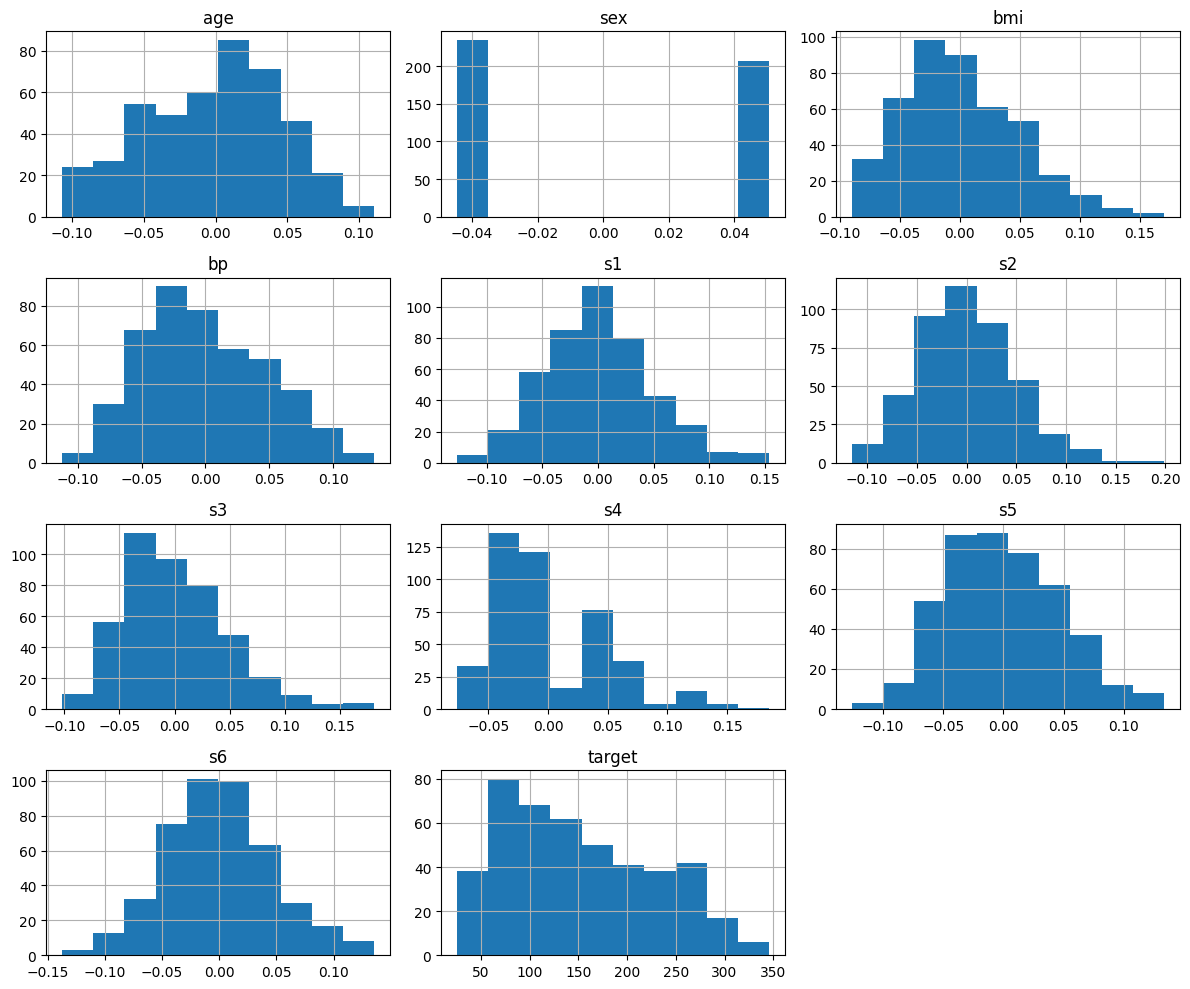

In [15]:
df = df.drop_duplicates()
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

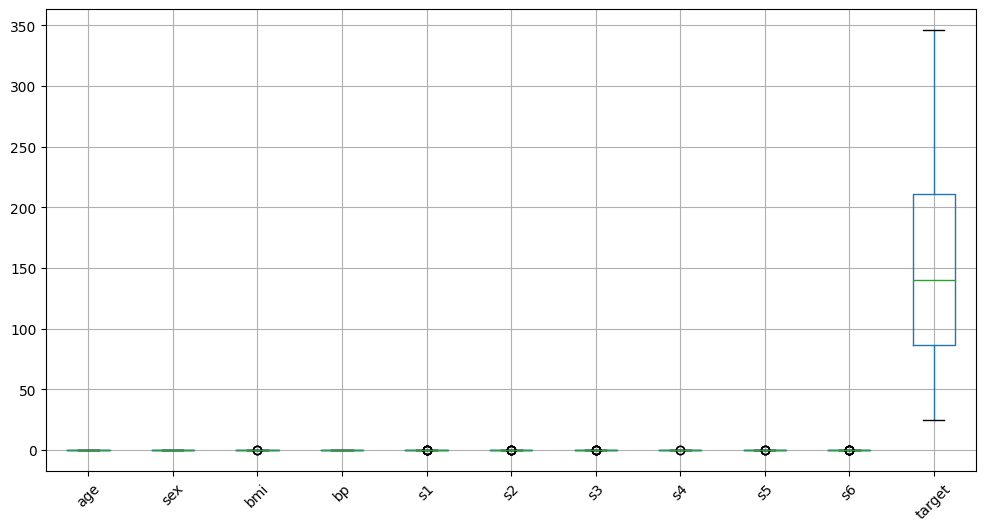

In [16]:
plt.figure(figsize=(12,6))
df.boxplot(rot=45)
plt.show()

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.800500,1.065488,1.297088,0.459841,-0.929746,-0.732065,-0.912451,-0.054499,0.418531,-0.370989
1,-0.039567,-0.938537,-1.082180,-0.553505,-0.177624,-0.402886,1.564414,-0.830301,-1.436589,-1.938479
2,1.793307,1.065488,0.934533,-0.119214,-0.958674,-0.718897,-0.680245,-0.054499,0.060156,-0.545154
3,-1.872441,-0.938537,-0.243771,-0.770650,0.256292,0.525397,-0.757647,0.721302,0.476983,-0.196823
4,0.113172,-0.938537,-0.764944,0.459841,0.082726,0.327890,0.171178,-0.054499,-0.672502,-0.980568


## Correlation Analysis

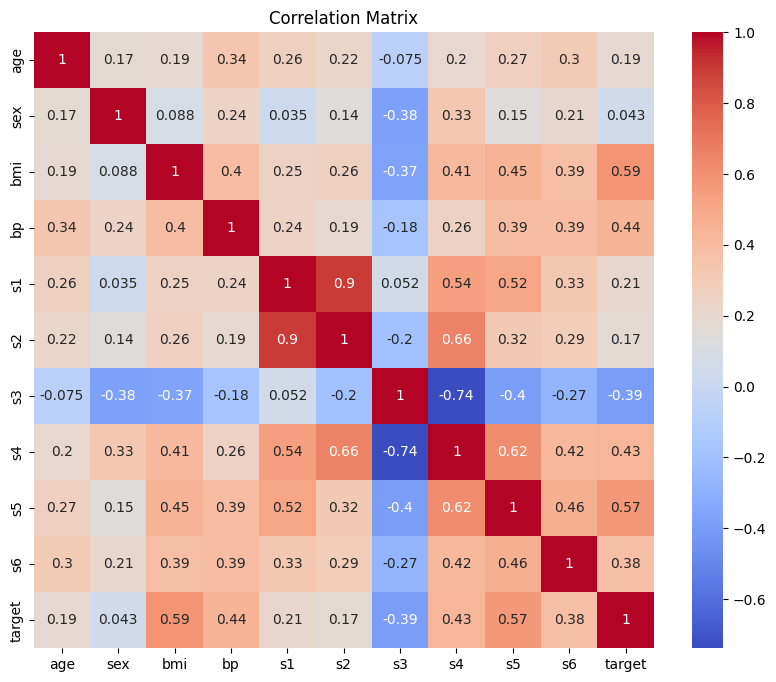

In [6]:
correlation = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

## Feature Selection

In [7]:
selector = SelectKBest(score_func=f_regression, k=5)

X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['bmi', 'bp', 's3', 's4', 's5'], dtype='object')


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

A Linear Regression model is used to learn the relationship between the selected medical features and the diabetes progression score. The model is trained using the training dataset and will later be used to predict diabetes progression on unseen data.

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

The trained model is evaluated using the testing dataset. Since this is a regression problem, the following evaluation metrics are used:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics indicate how accurately the model predicts diabetes progression.

In [10]:
y_pred = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

MAE: 43.92828580625927
MSE: 2936.4837818705064
RMSE: 54.18933273136427
R² Score: 0.4457531755875669


## Interpretation of Results

The evaluation metrics indicate that the Linear Regression model predicts diabetes progression with reasonable accuracy. Lower MAE, MSE, and RMSE values indicate smaller prediction errors, while a higher R² score indicates better predictive performance.

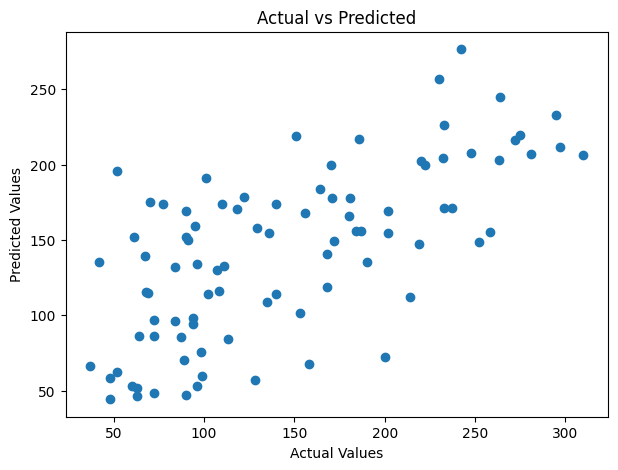

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

## Conclusion

A Linear Regression model was successfully developed to predict diabetes disease progression using patient medical data. After preprocessing, feature selection, and model training, the model was evaluated using regression metrics. The results indicate that the model can reasonably estimate the progression of diabetes, demonstrating the effectiveness of regression techniques for predicting continuous medical outcomes.